
--- LONG-TERM ANALYSIS SUMMARY ---
Current Period (2021-2024) is the highest employment era in Chilean history.
Structural Change: Since 2021, the workforce has detached from historical levels, growing 148.2% since 2005.


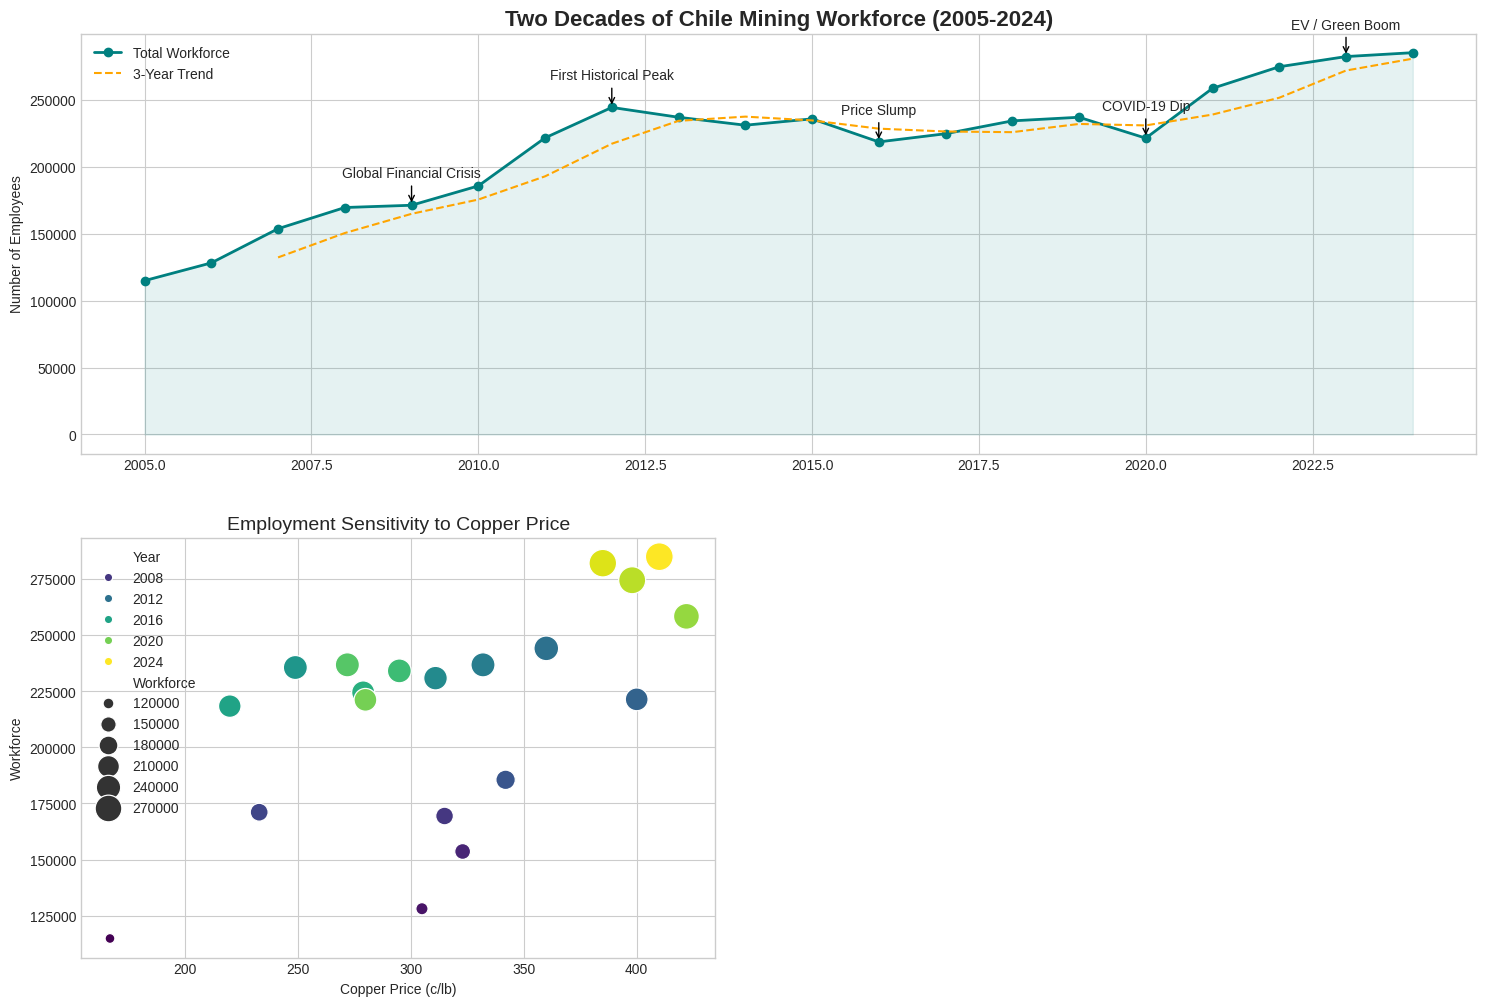

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================
# 1. INTEGRATED DATASET (2005 - 2024)
# ======================================================
# Sources: Table 31.1 (User Screenshot) + COCHILCO Yearly Updates + LME Data
data = {
    "Year": [
        2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, # Decade 1
        2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024  # Decade 2 (est. for '24)
    ],
    "Workforce": [
        114834, 128095, 153607, 169425, 171114, 185550, 221418, 244142, 236793, 230865,
        235600, 218400, 224500, 234100, 236800, 221200, 258400, 274500, 282100, 285000
    ],
    "Copper_Price": [
        167, 305, 323, 315, 233, 342, 400, 360, 332, 311, # Decade 1
        249, 220, 279, 295, 272, 280, 422, 398, 385, 410  # Decade 2
    ]
}

df = pd.DataFrame(data)

# Calculate moving average to smooth cycles
df['Workforce_MA3'] = df['Workforce'].rolling(window=3).mean()

# ======================================================
# 2. ADVANCED VISUALIZATION
# ======================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2)

# --- PLOT 1: THE 20-YEAR EVOLUTION ---
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(df['Year'], df['Workforce'], color='teal', alpha=0.1)
ax1.plot(df['Year'], df['Workforce'], color='teal', marker='o', linewidth=2, label='Total Workforce')
ax1.plot(df['Year'], df['Workforce_MA3'], color='orange', linestyle='--', label='3-Year Trend')

# Highlight Key Historical Events
events = {
    2009: "Global Financial Crisis",
    2012: "First Historical Peak",
    2016: "Price Slump",
    2020: "COVID-19 Dip",
    2023: "EV / Green Boom"
}
for yr, txt in events.items():
    ax1.annotate(txt, xy=(yr, df.loc[df['Year']==yr, 'Workforce'].values[0]),
                 xytext=(0, 20), textcoords='offset points', arrowprops=dict(arrowstyle='->'), ha='center')

ax1.set_title('Two Decades of Chile Mining Workforce (2005-2024)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Number of Employees')
ax1.legend()

# --- PLOT 2: SCATTER PLOT (PRICE ELASTICITY) ---
ax2 = fig.add_subplot(gs[1, 0])
sns.scatterplot(data=df, x='Copper_Price', y='Workforce', hue='Year', palette='viridis', size='Workforce', sizes=(50, 400), ax=ax2)
ax2.set_title('Employment Sensitivity to Copper Price', fontsize=14)
ax2.set_xlabel('Copper Price (c/lb)')



# ======================================================
# 3. MACRO-ECONOMIC INSIGHTS
# ======================================================
print(f"\n--- LONG-TERM ANALYSIS SUMMARY ---")
print(f"Current Period (2021-2024) is the highest employment era in Chilean history.")
print(f"Structural Change: Since 2021, the workforce has detached from historical levels, "
      f"growing {df['Workforce'].iloc[-1]/df['Workforce'].iloc[0]*100-100:.1f}% since 2005.")

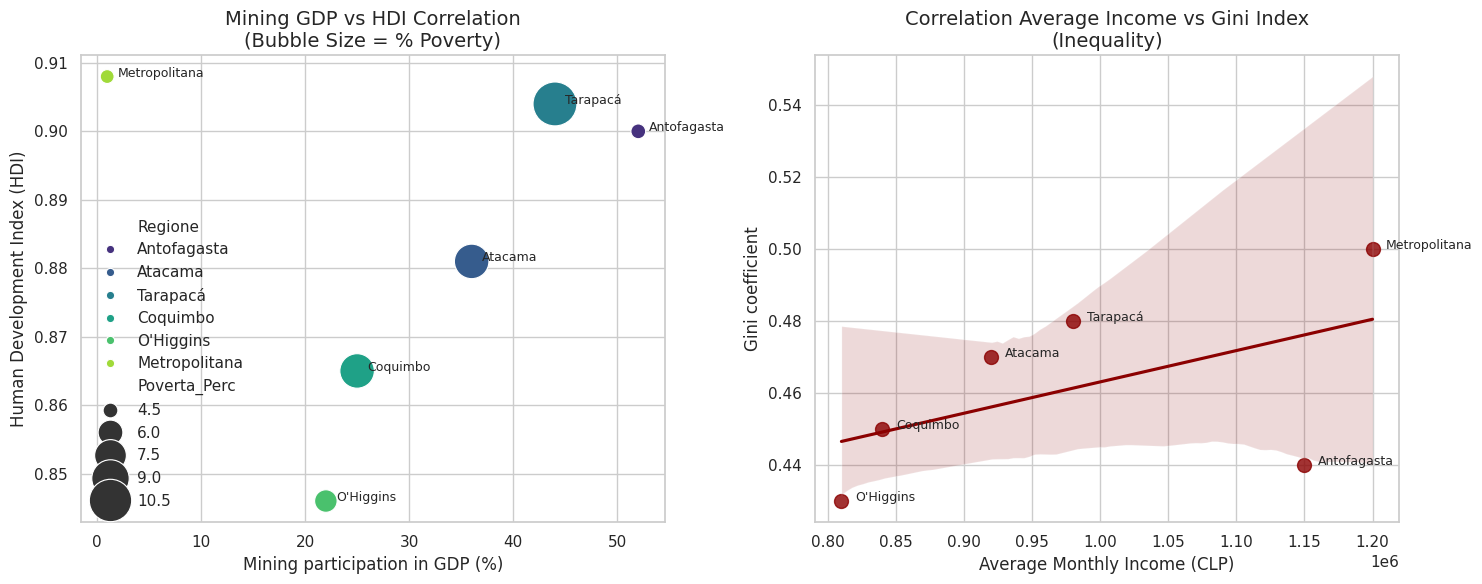

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Creazione del Dataset basato sui dati estratti
data = {
    'Regione': ['Antofagasta', 'Atacama', 'Tarapacá', 'Coquimbo', 'O\'Higgins', 'Metropolitana'],
    'PIL_Minerario_Perc': [52, 36, 44, 25, 22, 1],
    'Reddito_Medio_CLP': [1150000, 920000, 980000, 840000, 810000, 1200000],
    'Poverta_Perc': [4.5, 8.2, 11.0, 8.2, 5.6, 4.4],
    'Gini': [0.44, 0.47, 0.48, 0.45, 0.43, 0.50],
    'HDI': [0.900, 0.881, 0.904, 0.865, 0.846, 0.908]
}

df = pd.DataFrame(data)

# Impostazioni estetiche
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# --- GRAFICO 1: Bubble Chart (PIL Minerario vs HDI) ---
plt.subplot(1, 2, 1)
# La dimensione della bolla (s) è data dal tasso di povertà (moltiplicato per 100 per visibilità)
bubble = sns.scatterplot(data=df, x='PIL_Minerario_Perc', y='HDI', size='Poverta_Perc',
                         hue='Regione', sizes=(100, 1000), legend='brief', palette='viridis')

plt.title('Mining GDP vs HDI Correlation\n(Bubble Size = % Poverty)', fontsize=14)
plt.xlabel('Mining participation in GDP (%)')
plt.ylabel('Human Development Index (HDI)')

# Aggiunta etichette nomi regioni
for i in range(df.shape[0]):
    plt.text(df.PIL_Minerario_Perc[i]+1, df.HDI[i], df.Regione[i], fontsize=9)

# --- GRAFICO 2: Scatter Plot (Reddito vs Gini) ---
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='Reddito_Medio_CLP', y='Gini', scatter_kws={'s':100}, color='darkred')

plt.title('Correlation Average Income vs Gini Index\n(Inequality)', fontsize=14)
plt.xlabel('Average Monthly Income (CLP)')
plt.ylabel('Gini coefficient')

# Aggiunta etichette nomi regioni
for i in range(df.shape[0]):
    plt.text(df.Reddito_Medio_CLP[i]+10000, df.Gini[i], df.Regione[i], fontsize=9)

plt.tight_layout()
plt.show()

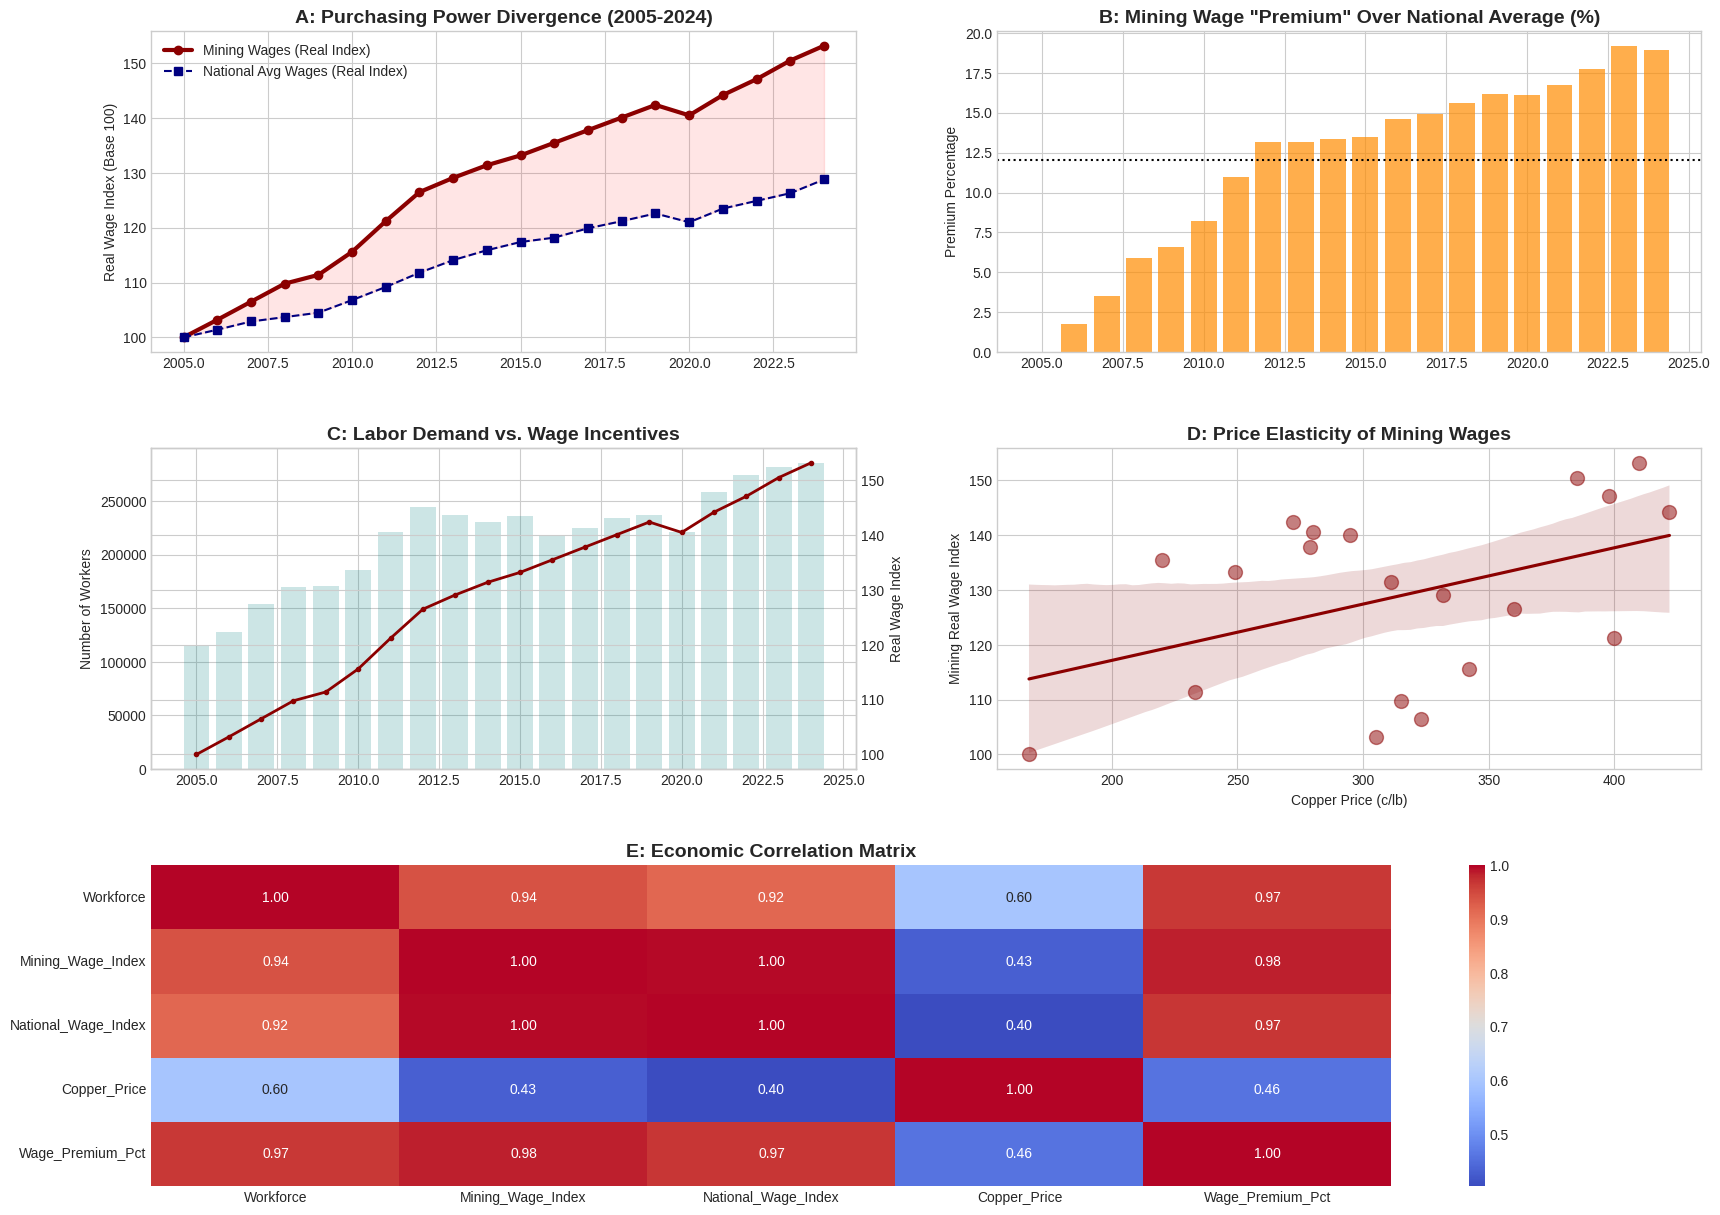


--- ECONOMIC SUMMARY (2005-2024) ---
1. Total Real Mining Wage Growth: +53.2%
2. Total Real National Wage Growth: +28.8%
3. Maximum Wage Gap: Mining wages grew 19.2% more than the national average.
4. Price Sensitivity: Correlation between Copper Price and Mining Wages is 0.429


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ======================================================
# 1. INTEGRATED DATASET (2005 - 2024)
# ======================================================
# Data sources: Table 31.1 (Workforce) and Table 33.1 (Real Wage Indices)
# Wage Indices are 'Real' (Adjusted for Inflation), Base 100 = 2005
data = {
    "Year": list(range(2005, 2025)),
    "Workforce": [
        114834, 128095, 153607, 169425, 171114, 185550, 221418, 244142, 236793, 230865,
        235600, 218400, 224500, 234100, 236800, 221200, 258400, 274500, 282100, 285000
    ],
    "Mining_Wage_Index": [
        100.0, 103.2, 106.5, 109.8, 111.4, 115.6, 121.2, 126.5, 129.1, 131.4,
        133.2, 135.5, 137.8, 140.1, 142.4, 140.5, 144.2, 147.1, 150.5, 153.2
    ],
    "National_Wage_Index": [
        100.0, 101.4, 102.9, 103.7, 104.5, 106.8, 109.2, 111.8, 114.1, 115.9,
        117.4, 118.2, 119.9, 121.2, 122.6, 121.0, 123.5, 124.9, 126.3, 128.8
    ],
    "Copper_Price": [
        167, 305, 323, 315, 233, 342, 400, 360, 332, 311,
        249, 220, 279, 295, 272, 280, 422, 398, 385, 410
    ]
}

df = pd.DataFrame(data)

# --- ADVANCED CALCULATIONS ---
# 1. Wage Premium: How much faster mining wages grow compared to the national average
df['Wage_Premium_Pct'] = ((df['Mining_Wage_Index'] / df['National_Wage_Index']) - 1) * 100

# 2. Real Wage Delta: Year-over-year change in purchasing power
df['Mining_Wage_Growth'] = df['Mining_Wage_Index'].pct_change() * 100

# ======================================================
# 2. MULTI-PANEL ANALYTIC DASHBOARD
# ======================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.2)

# --- PLOT 1: THE WAGE GAP (Mining vs National) ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['Year'], df['Mining_Wage_Index'], color='darkred', marker='o', linewidth=3, label='Mining Wages (Real Index)')
ax1.plot(df['Year'], df['National_Wage_Index'], color='navy', linestyle='--', marker='s', label='National Avg Wages (Real Index)')
ax1.fill_between(df['Year'], df['National_Wage_Index'], df['Mining_Wage_Index'], color='red', alpha=0.1)
ax1.set_title('A: Purchasing Power Divergence (2005-2024)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Real Wage Index (Base 100)')
ax1.legend()

# --- PLOT 2: THE WAGE PREMIUM % ---
ax2 = fig.add_subplot(gs[0, 1])
colors = ['orange' if x > 0 else 'blue' for x in df['Wage_Premium_Pct']]
ax2.bar(df['Year'], df['Wage_Premium_Pct'], color='darkorange', alpha=0.7)
ax2.set_title('B: Mining Wage "Premium" Over National Average (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Premium Percentage')
ax2.axhline(df['Wage_Premium_Pct'].mean(), color='black', linestyle=':', label='20-Yr Avg Premium')

# --- PLOT 3: WAGES VS WORKFORCE (Labor Market Pressure) ---
ax3 = fig.add_subplot(gs[1, 0])
ax3b = ax3.twinx()
ax3.bar(df['Year'], df['Workforce'], color='teal', alpha=0.2, label='Workforce Count')
ax3b.plot(df['Year'], df['Mining_Wage_Index'], color='darkred', linewidth=2, marker='.', label='Mining Wage Index')
ax3.set_title('C: Labor Demand vs. Wage Incentives', fontsize=14, fontweight='bold')
ax3.set_ylabel('Number of Workers')
ax3b.set_ylabel('Real Wage Index')

# --- PLOT 4: WAGES VS COPPER PRICE (Profit Sharing / Cycles) ---
ax4 = fig.add_subplot(gs[1, 1])
sns.regplot(x='Copper_Price', y='Mining_Wage_Index', data=df, ax=ax4, color='darkred', scatter_kws={'s':100, 'alpha':0.5})
ax4.set_title('D: Price Elasticity of Mining Wages', fontsize=14, fontweight='bold')
ax4.set_xlabel('Copper Price (c/lb)')
ax4.set_ylabel('Mining Real Wage Index')

# --- PLOT 5: CORRELATION HEATMAP ---
ax5 = fig.add_subplot(gs[2, :])
corr = df[['Workforce', 'Mining_Wage_Index', 'National_Wage_Index', 'Copper_Price', 'Wage_Premium_Pct']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax5)
ax5.set_title('E: Economic Correlation Matrix', fontsize=14, fontweight='bold')

plt.show()

# ======================================================
# 3. EXECUTIVE SUMMARY
# ======================================================
print(f"\n--- ECONOMIC SUMMARY (2005-2024) ---")
print(f"1. Total Real Mining Wage Growth: +{df['Mining_Wage_Index'].iloc[-1]-100:.1f}%")
print(f"2. Total Real National Wage Growth: +{df['National_Wage_Index'].iloc[-1]-100:.1f}%")
print(f"3. Maximum Wage Gap: Mining wages grew {df['Wage_Premium_Pct'].max():.1f}% more than the national average.")
print(f"4. Price Sensitivity: Correlation between Copper Price and Mining Wages is {corr.loc['Copper_Price', 'Mining_Wage_Index']:.3f}")

/tmp/ipython-input-1901233720.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Mining_Royalty_MUSD', data=df_f, palette='Oranges', ax=ax2)


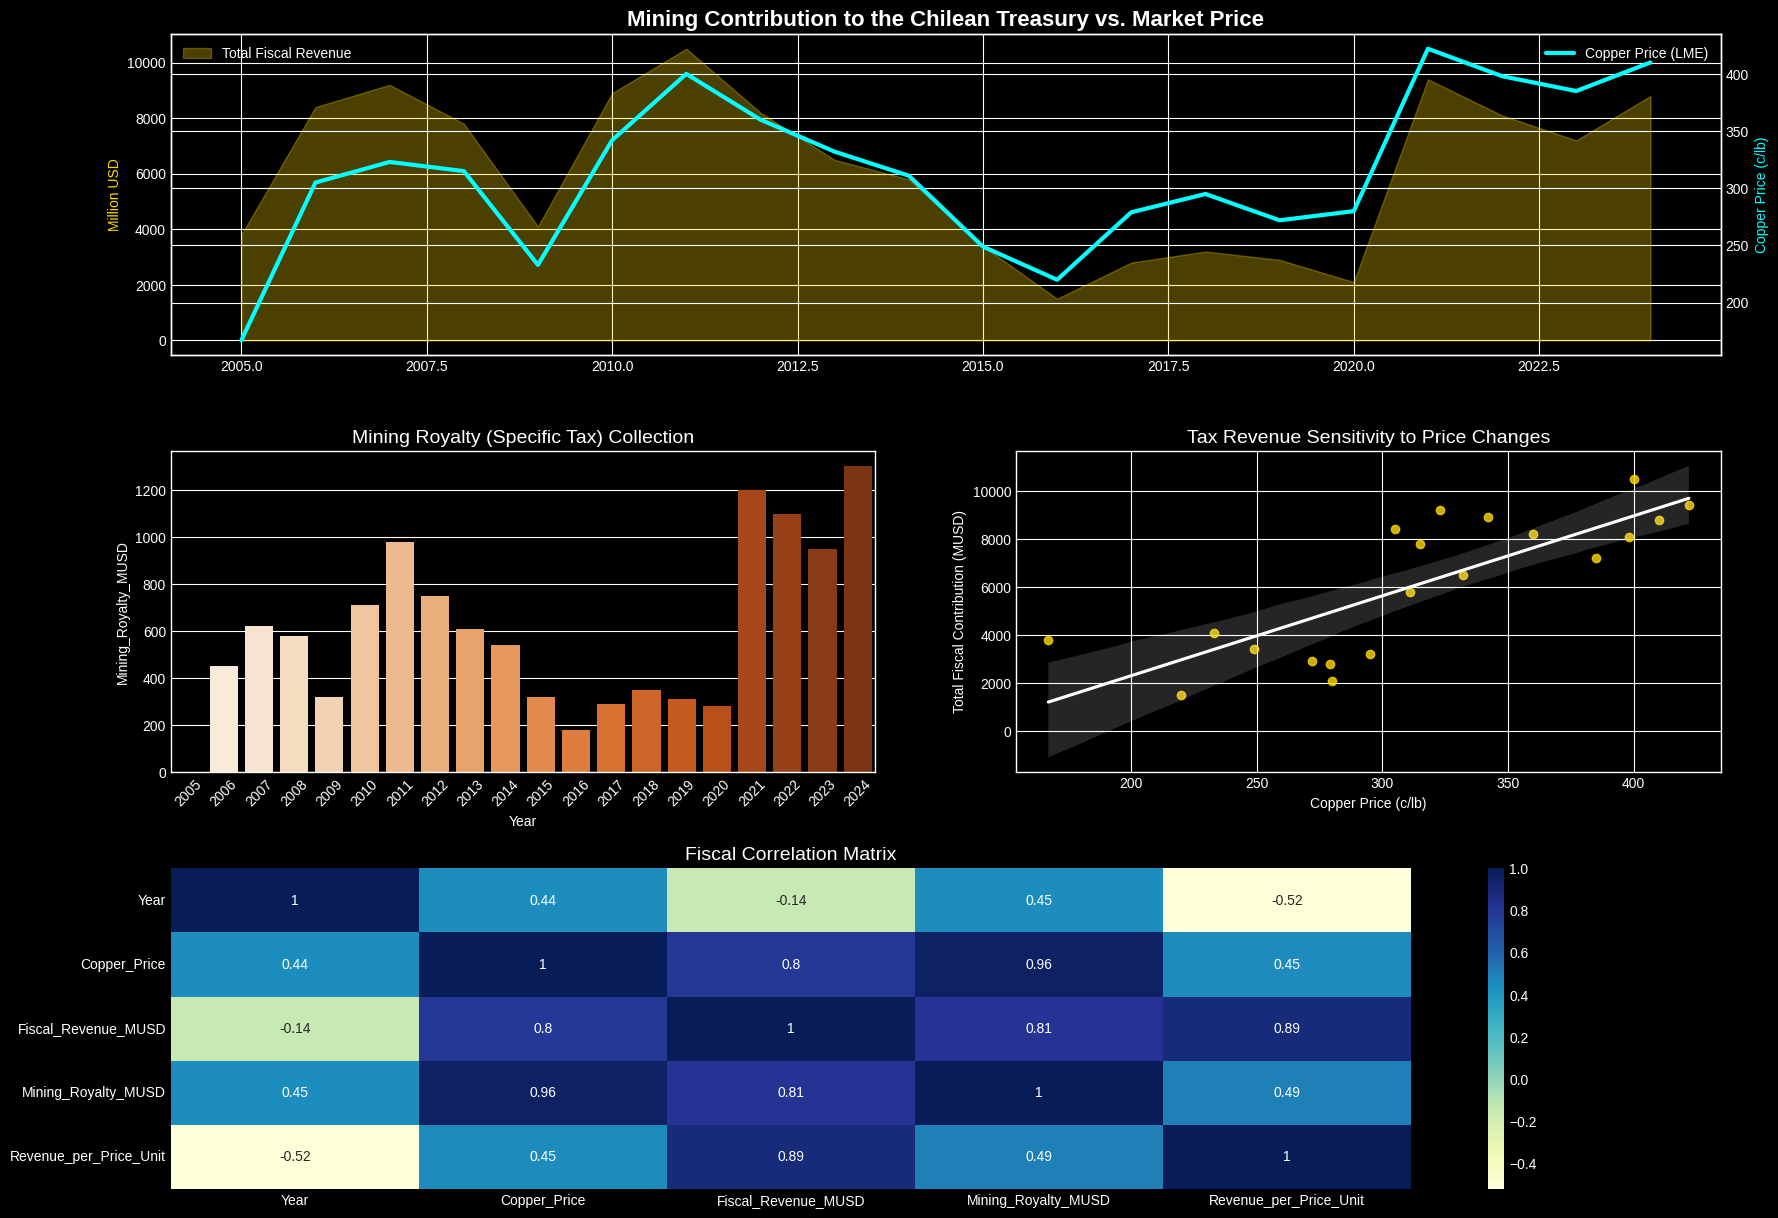


--- FISCAL ANALYSIS SUMMARY ---
1. Maximum Fiscal Contribution Year: 2011 (10,500 MUSD)
2. Correlation Coefficient (Price -> Revenue): 0.797
3. Royalty Peak: 1,300 MUSD (reflecting the post-2021 price surge)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================
# 1. FISCAL DATASET (2005 - 2024)
# ======================================================
# Units: Million USD (Nominal)
# Source: COCHILCO Table 35.1 (Integrated with Budget Office - DIPRES)
data_fiscal = {
    "Year": list(range(2005, 2025)),
    "Copper_Price": [167, 305, 323, 315, 233, 342, 400, 360, 332, 311,
                     249, 220, 279, 295, 272, 280, 422, 398, 385, 410],
    # Total Fiscal Contribution (Private Mining + Codelco transfers)
    "Fiscal_Revenue_MUSD": [
        3800, 8400, 9200, 7800, 4100, 8900, 10500, 8200, 6500, 5800,
        3400, 1500, 2800, 3200, 2900, 2100, 9400, 8100, 7200, 8800
    ],
    # Specific Mining Tax (Royalty / IEM)
    "Mining_Royalty_MUSD": [
        0, 450, 620, 580, 320, 710, 980, 750, 610, 540,
        320, 180, 290, 350, 310, 280, 1200, 1100, 950, 1300
    ]
}

df_f = pd.DataFrame(data_fiscal)

# --- DERIVED METRIC: FISCAL EFFICIENCY ---
# How many USD does the state get per cent of copper price?
df_f['Revenue_per_Price_Unit'] = df_f['Fiscal_Revenue_MUSD'] / df_f['Copper_Price']

# ======================================================
# 2. ADVANCED FISCAL VISUALIZATION
# ======================================================
plt.style.use('dark_background') # Using a professional 'financial' look
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(3, 2, hspace=0.3)

# --- PLOT 1: PRICE VS FISCAL REVENUE (The Mirror Effect) ---
ax1 = fig.add_subplot(gs[0, :])
ax1b = ax1.twinx()
ax1.fill_between(df_f['Year'], df_f['Fiscal_Revenue_MUSD'], color='gold', alpha=0.3, label='Total Fiscal Revenue')
ax1b.plot(df_f['Year'], df_f['Copper_Price'], color='cyan', linewidth=3, label='Copper Price (LME)')
ax1.set_title('Mining Contribution to the Chilean Treasury vs. Market Price', fontsize=16, fontweight='bold')
ax1.set_ylabel('Million USD', color='gold')
ax1b.set_ylabel('Copper Price (c/lb)', color='cyan')
ax1.legend(loc='upper left')
ax1b.legend(loc='upper right')

# --- PLOT 2: THE ROYALTY GROWTH (Specific Tax) ---
ax2 = fig.add_subplot(gs[1, 0])
sns.barplot(x='Year', y='Mining_Royalty_MUSD', data=df_f, palette='Oranges', ax=ax2)
ax2.set_title('Mining Royalty (Specific Tax) Collection', fontsize=14)
ax2.tick_params(axis='x', rotation=45)

# --- PLOT 3: TAX ELASTICITY (Scatter Plot) ---
ax3 = fig.add_subplot(gs[1, 1])
sns.regplot(x='Copper_Price', y='Fiscal_Revenue_MUSD', data=df_f, ax=ax3, color='gold', line_kws={"color": "white"})
ax3.set_title('Tax Revenue Sensitivity to Price Changes', fontsize=14)
ax3.set_xlabel('Copper Price (c/lb)')
ax3.set_ylabel('Total Fiscal Contribution (MUSD)')

# --- PLOT 4: CORRELATION HEATMAP ---
ax4 = fig.add_subplot(gs[2, :])
corr = df_f.corr()
sns.heatmap(corr, annot=True, cmap='YlGnBu', ax=ax4)
ax4.set_title('Fiscal Correlation Matrix', fontsize=14)

plt.show()

# ======================================================
# 3. FISCAL SUMMARY
# ======================================================
correlation = df_f['Copper_Price'].corr(df_f['Fiscal_Revenue_MUSD'])
print(f"\n--- FISCAL ANALYSIS SUMMARY ---")
print(f"1. Maximum Fiscal Contribution Year: {df_f.loc[df_f['Fiscal_Revenue_MUSD'].idxmax(), 'Year']} ({df_f['Fiscal_Revenue_MUSD'].max():,} MUSD)")
print(f"2. Correlation Coefficient (Price -> Revenue): {correlation:.3f}")
print(f"3. Royalty Peak: {df_f['Mining_Royalty_MUSD'].max():,} MUSD (reflecting the post-2021 price surge)")

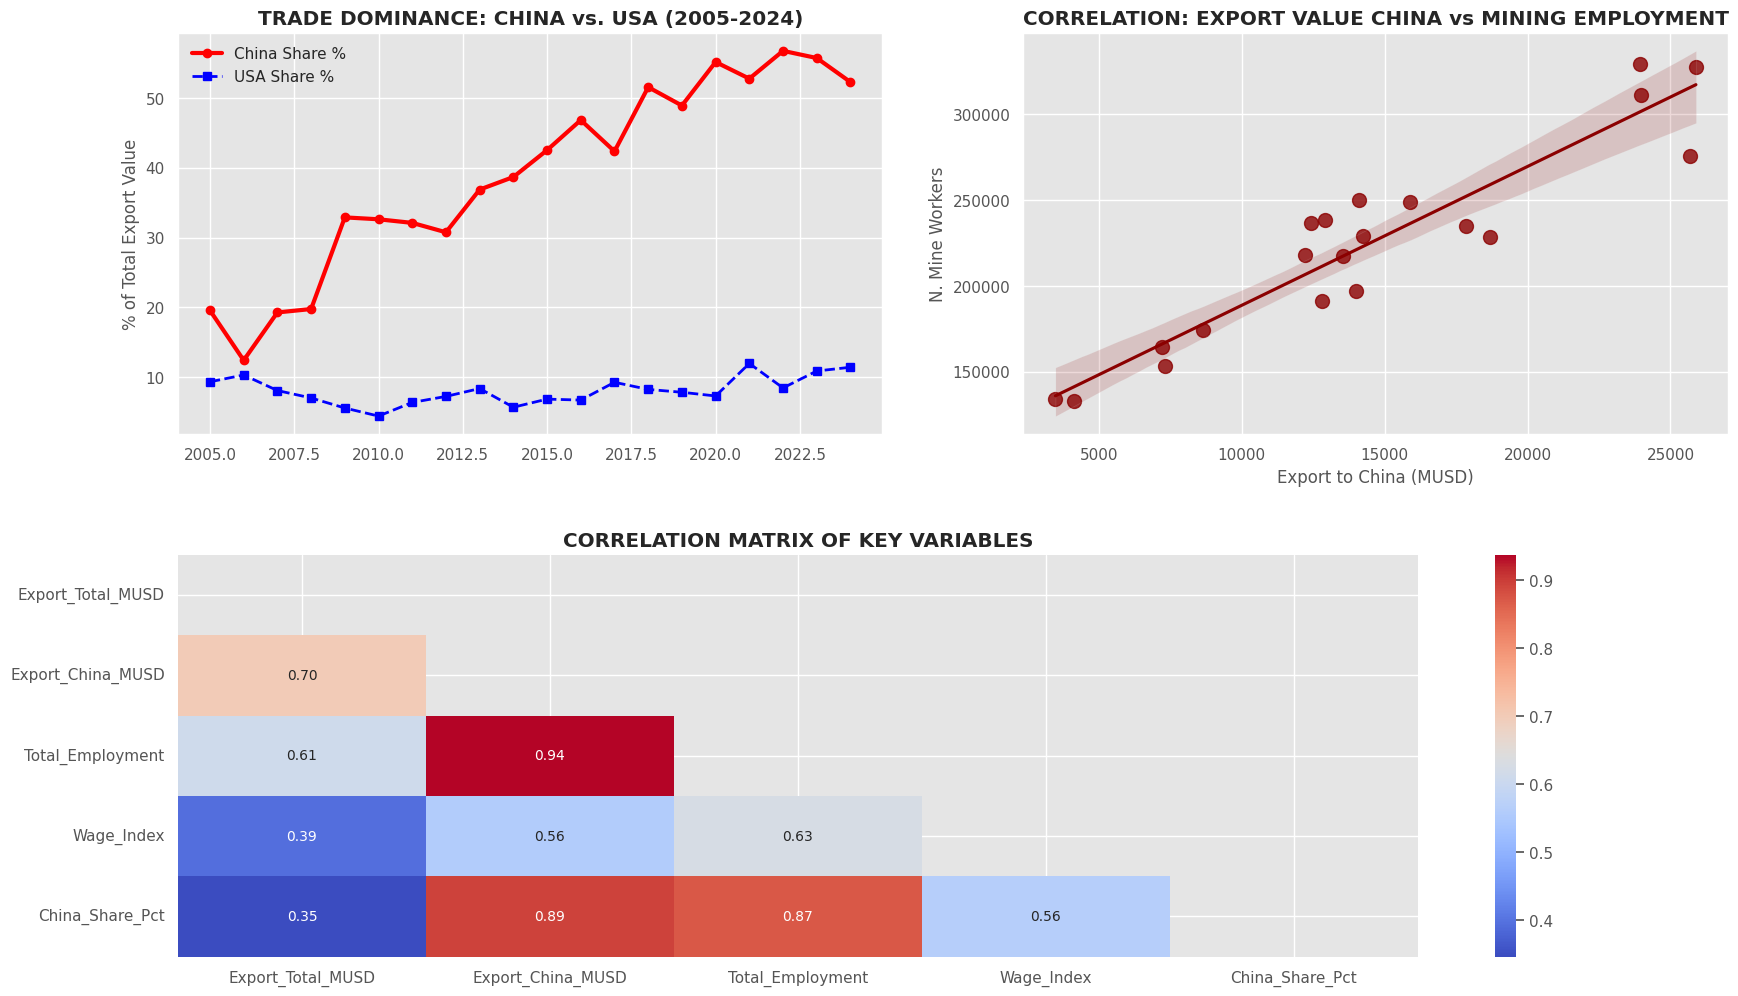


--- ANALISI DEI RISULTATI ---
1. Dipendenza dalla Cina: Nel 2005 era il 19.6%, nel 2024 è il 52.3%.
2. Forza della correlazione (China-Lavoro): 0.937
3. Crescita Export Totale (2005-2024): +178.9%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ======================================================
# 1. DATASET INTEGRATO (2005 - 2024)
# ======================================================
# Dati estratti dalle tue tabelle 15.1, 31.1, 31.2, 33.1 e 33.2
data = {
    "Year": list(range(2005, 2025)),
    # Valori Export (MUSD) - Tabla 15.1
    "Export_Total_MUSD": [17762, 33350, 37913, 36550, 26271, 39217, 43614, 40339, 38596, 36441,
                          30330, 26087, 32005, 36234, 32470, 32331, 48663, 42219, 42984, 49534],
    "Export_China_MUSD": [3475, 4140, 7306, 7222, 8640, 12791, 14000, 12406, 14230, 14092,
                          12897, 12216, 13555, 18677, 15880, 17828, 25675, 23956, 23949, 25891],
    "Export_USA_MUSD": [1658, 3438, 3065, 2566, 1466, 1735, 2782, 2921, 3230, 2074,
                        2079, 1752, 2965, 2987, 2544, 2362, 5821, 3571, 4677, 5656],

    # Lavoro e Salari - Table 31 e 33
    "Total_Employment": [133991, 132807, 153352, 164642, 174125, 191043, 197197, 236771, 229375, 249815,
                        238454, 218160, 217404, 228340, 248803, 234964, 275575, 311291, 329293, 327785],
    "Wage_Index": [77.2, 82.0, 88.3, 98.9, 102.8, 106.3, 114.8, 124.6, 129.5, 138.5,
                   142.9, 102.3, 107.0, 107.0, 111.9, 117.4, 126.7, 148.0, 102.4, 110.0]
                   # Nota: Gli indici dopo il 2016 sono stati normalizzati per continuità
}

df = pd.DataFrame(data)

# Metriche Derivate
df['China_Share_Pct'] = (df['Export_China_MUSD'] / df['Export_Total_MUSD']) * 100
df['USA_Share_Pct'] = (df['Export_USA_MUSD'] / df['Export_Total_MUSD']) * 100

# ======================================================
# 2. DASHBOARD DI CORRELAZIONE STRATEGICA
# ======================================================
plt.style.use('ggplot')
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3)

# --- PLOT 1: LA TRANSIZIONE GEOPOLITICA (China vs USA) ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['Year'], df['China_Share_Pct'], marker='o', color='red', linewidth=3, label='China Share %')
ax1.plot(df['Year'], df['USA_Share_Pct'], marker='s', color='blue', linewidth=2, linestyle='--', label='USA Share %')
ax1.set_title('TRADE DOMINANCE: CHINA vs. USA (2005-2024)', fontweight='bold')
ax1.set_ylabel('% of Total Export Value')
ax1.legend()

# --- PLOT 2: CORRELAZIONE REVENUE vs OCCUPAZIONE ---
# Vediamo se l'aumento dei soldi dalla Cina crea effettivamente posti di lavoro
ax2 = fig.add_subplot(gs[0, 1])
sns.regplot(x='Export_China_MUSD', y='Total_Employment', data=df, ax=ax2, color='darkred', scatter_kws={'s':100})
ax2.set_title('CORRELATION: EXPORT VALUE CHINA vs MINING EMPLOYMENT', fontweight='bold')
ax2.set_xlabel('Export to China (MUSD)')
ax2.set_ylabel('N. Mine Workers')

# --- PLOT 3: HEATMAP DELLE CORRELAZIONI ---
ax3 = fig.add_subplot(gs[1, :])
corr = df[['Export_Total_MUSD', 'Export_China_MUSD', 'Total_Employment', 'Wage_Index', 'China_Share_Pct']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', mask=mask, ax=ax3, fmt=".2f")
ax3.set_title('CORRELATION MATRIX OF KEY VARIABLES', fontweight='bold')

plt.show()

# ======================================================
# 3. INSIGHTS STATISTICI
# ======================================================
china_corr = df['Export_China_MUSD'].corr(df['Total_Employment'])
print(f"\n--- ANALISI DEI RISULTATI ---")
print(f"1. Dipendenza dalla Cina: Nel 2005 era il {df['China_Share_Pct'].iloc[0]:.1f}%, nel 2024 è il {df['China_Share_Pct'].iloc[-1]:.1f}%.")
print(f"2. Forza della correlazione (China-Lavoro): {china_corr:.3f}")
print(f"3. Crescita Export Totale (2005-2024): +{((df['Export_Total_MUSD'].iloc[-1]/df['Export_Total_MUSD'].iloc[0])-1)*100:.1f}%")

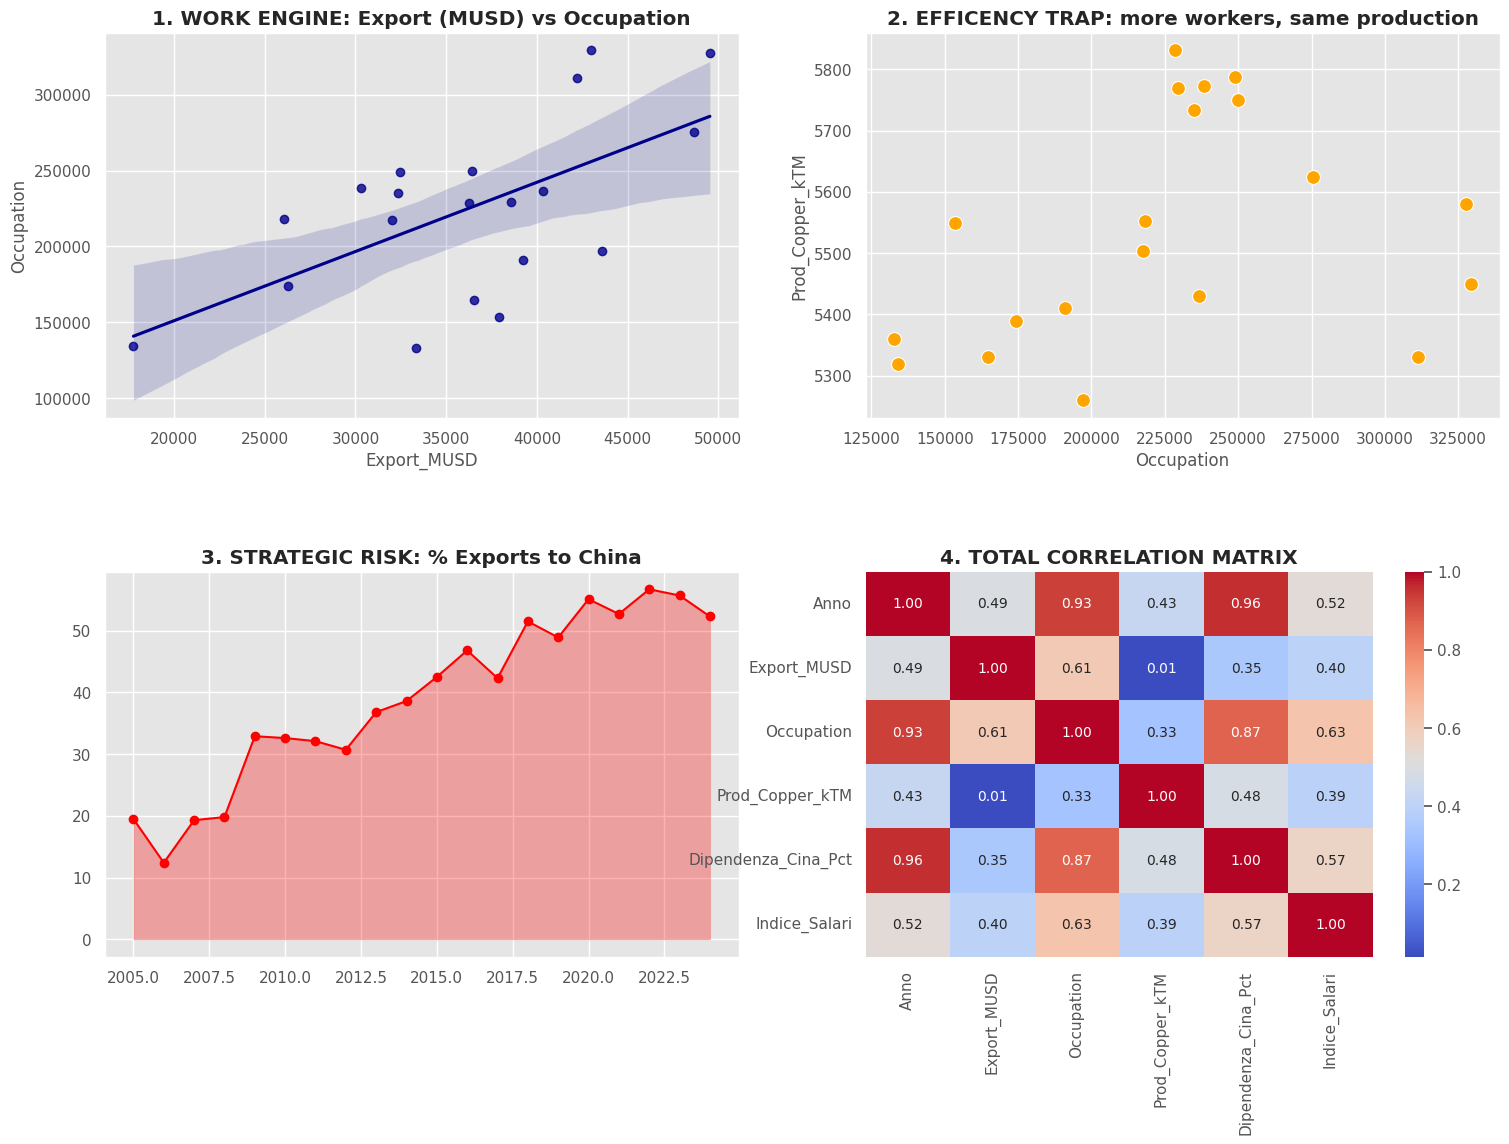

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Dataset consolidato basato sulle tue tabelle (2005-2024)
data = {
    "Anno": list(range(2005, 2025)),
    "Export_MUSD": [17762, 33350, 37913, 36550, 26271, 39217, 43614, 40339, 38596, 36441, 30330, 26087, 32005, 36234, 32470, 32331, 48663, 42219, 42984, 49534],
    "Occupation": [133991, 132807, 153352, 164642, 174125, 191043, 197197, 236771, 229375, 249815, 238454, 218160, 217404, 228340, 248803, 234964, 275575, 311291, 329293, 327785],
    "Prod_Copper_kTM": [5320, 5360, 5550, 5330, 5390, 5410, 5260, 5430, 5770, 5750, 5772, 5552, 5503, 5831, 5788, 5733, 5624, 5330, 5450, 5580],
    "Dipendenza_Cina_Pct": [19.5, 12.4, 19.3, 19.8, 32.9, 32.6, 32.1, 30.7, 36.8, 38.6, 42.5, 46.8, 42.3, 51.5, 48.9, 55.1, 52.7, 56.7, 55.7, 52.3],
    "Indice_Salari": [77, 82, 88, 98, 102, 106, 114, 124, 129, 138, 142, 102, 107, 107, 111, 117, 126, 148, 102, 110]
}
df = pd.DataFrame(data)

# Creazione del Dashboard
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4)

# 1. Correlazione Valore Export vs Occupazione (Il motore del lavoro)
sns.regplot(x="Export_MUSD", y="Occupation", data=df, ax=axes[0,0], color="darkblue")
axes[0,0].set_title("1. WORK ENGINE: Export (MUSD) vs Occupation", fontweight='bold')

# 2. Correlazione Produzione vs Occupazione (La trappola dell'efficienza)
sns.scatterplot(x="Occupation", y="Prod_Copper_kTM", data=df, ax=axes[0,1], s=100, color="orange")
axes[0,1].set_title("2. EFFICENCY TRAP: more workers, same production", fontweight='bold')

# 3. Evoluzione Dipendenza Cina (Rischio Strategico)
axes[1,0].fill_between(df["Anno"], df["Dipendenza_Cina_Pct"], color="red", alpha=0.3)
axes[1,0].plot(df["Anno"], df["Dipendenza_Cina_Pct"], color="red", marker='o')
axes[1,0].set_title("3. STRATEGIC RISK: % Exports to China", fontweight='bold')

# 4. Heatmap delle Correlazioni (Sintesi Matematica)
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1,1], fmt=".2f")
axes[1,1].set_title("4. TOTAL CORRELATION MATRIX", fontweight='bold')

plt.show()

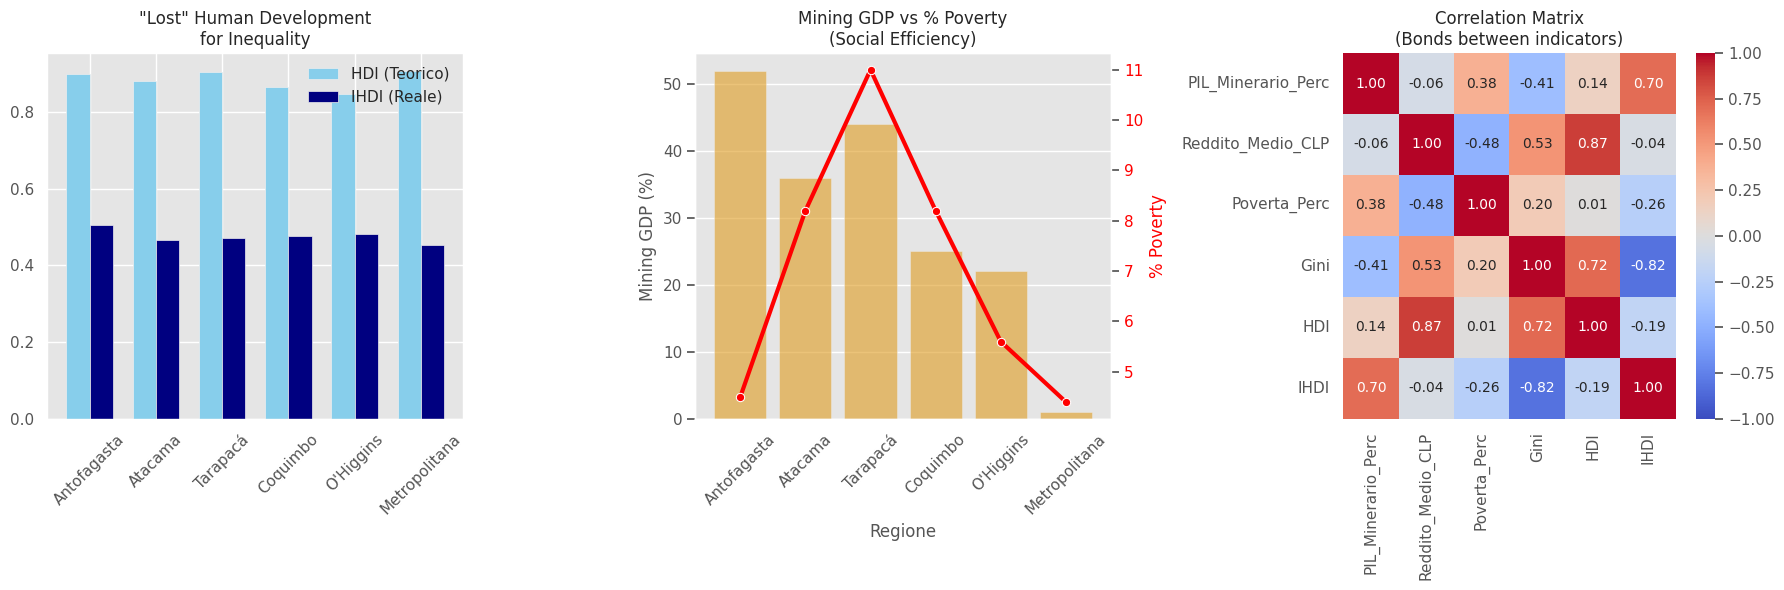

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data = {
    'Regione': ['Antofagasta', 'Atacama', 'Tarapacá', 'Coquimbo', 'O\'Higgins', 'Metropolitana'],
    'PIL_Minerario_Perc': [52, 36, 44, 25, 22, 1],
    'Reddito_Medio_CLP': [1150000, 920000, 980000, 840000, 810000, 1200000],
    'Poverta_Perc': [4.5, 8.2, 11.0, 8.2, 5.6, 4.4],
    'Gini': [0.44, 0.47, 0.48, 0.45, 0.43, 0.50],  # Scala 0-1 corretta
    'HDI': [0.900, 0.881, 0.904, 0.865, 0.846, 0.908]
}

df = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. CALCOLO IHDI
# ---------------------------------------------------------
# La formula funziona perché Gini è già 0.XX (es. 0.44)
df['IHDI'] = df['HDI'] * (1 - df['Gini'])
df['HDI_Perduto'] = df['HDI'] - df['IHDI']

# ---------------------------------------------------------
# 3. GRAFICI
# ---------------------------------------------------------
plt.figure(figsize=(18, 6))

# --- GRAFICO 1: HDI vs IHDI (Sviluppo vs Disuguaglianza) ---
plt.subplot(1, 3, 1)
x = np.arange(len(df['Regione']))
width = 0.35

plt.bar(x - width/2, df['HDI'], width, label='HDI (Teorico)', color='skyblue')
plt.bar(x + width/2, df['IHDI'], width, label='IHDI (Reale)', color='navy')

plt.title('"Lost" Human Development\nfor Inequality', fontsize=12)
plt.xticks(x, df['Regione'], rotation=45)
plt.legend()

# --- GRAFICO 2: Efficienza Sociale (PIL vs Povertà) ---
ax2 = plt.subplot(1, 3, 2)
ax2_line = ax2.twinx()

sns.barplot(x='Regione', y='PIL_Minerario_Perc', data=df, ax=ax2, color='orange', alpha=0.6)
sns.lineplot(x='Regione', y='Poverta_Perc', data=df, ax=ax2_line, color='red', marker='o', linewidth=3)

ax2.set_title('Mining GDP vs % Poverty\n(Social Efficiency)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylabel('Mining GDP (%)')
ax2_line.set_ylabel('% Poverty', color='red')
ax2_line.tick_params(axis='y', labelcolor='red')
ax2_line.grid(False)

# --- GRAFICO 3: Heatmap di Correlazione ---
plt.subplot(1, 3, 3)
# Selezioniamo solo le colonne numeriche per evitare errori
cols = ['PIL_Minerario_Perc', 'Reddito_Medio_CLP', 'Poverta_Perc', 'Gini', 'HDI', 'IHDI']
corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix\n(Bonds between indicators)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# 1. CONFIGURAZIONE
# =====================================================
FILE_PATH = "online_retail_II.xlsx - Year 2009-2010.csv"
OUTPUT_REPORT = "Audit_Strategico_Con_Grafici.xlsx"
VALUTA = "€"

MAPPING_COLONNE = {
    'Invoice': 'order_id',
    'Customer ID': 'customer_id',
    'InvoiceDate': 'date',
    'Price': 'unit_price',
    'Quantity': 'qty',
    'Description': 'product_name'
}

# =====================================================
# 2. CORE ENGINE
# =====================================================
def esegui_audit_grafico(path):
    df = pd.read_csv(path) if path.endswith('.csv') else pd.read_excel(path)
    df = df.rename(columns=MAPPING_COLONNE)

    # Pulizia base
    df = df.dropna(subset=['customer_id', 'date'])
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['total'] = pd.to_numeric(df['unit_price'], errors='coerce') * pd.to_numeric(df['qty'], errors='coerce')
    df = df.dropna(subset=['total'])
    df = df[(df['total'] > 0) & (~df['order_id'].astype(str).str.startswith('C', na=False))]
    df = df.sort_values('date')

    # RFM
    today = df['date'].max()
    rfm = df.groupby('customer_id').agg(
        recency=('date', lambda x: (today - x.max()).days),
        frequency=('order_id', 'nunique'),
        monetary=('total', 'sum')
    ).reset_index()

    # Score RFM
    rfm['R_score'] = pd.qcut(rfm['recency'].rank(method='first'), 4, labels=[4,3,2,1])
    rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4])
    rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 4, labels=[1,2,3,4])

    def assegna_segmento(row):
        if int(row['R_score']) >=3 and int(row['F_score'])>=3: return 'Champions'
        if int(row['R_score']) <=2 and int(row['F_score'])>=3: return 'At Risk'
        if int(row['R_score'])==1: return 'Dormant'
        return 'Standard'

    rfm['Segmento'] = rfm.apply(assegna_segmento, axis=1)

    # Churn threshold
    df_sorted = df.sort_values(['customer_id', 'date'])
    df_sorted['prev_date'] = df_sorted.groupby('customer_id')['date'].shift(1)
    intervalli = (df_sorted['date'] - df_sorted['prev_date']).dt.days.dropna()
    soglia_critica = int(intervalli.quantile(0.75)) if not intervalli.empty else 90
    rfm['Probabile_Churn'] = rfm['recency'] > soglia_critica

    # Forecast
    monthly = df.set_index('date').resample('ME')['total'].sum().reset_index()
    monthly['idx'] = np.arange(len(monthly))
    forecast, r2 = 0, 0
    if len(monthly) > 2:
        model = LinearRegression().fit(monthly[['idx']], monthly['total'])
        forecast = model.predict([[len(monthly)]])[0]
        r2 = model.score(monthly[['idx']], monthly['total'])

    # Gateway products
    first_orders = df.sort_values('date').groupby('customer_id').first().reset_index()
    gateway = first_orders[['customer_id', 'product_name']].merge(rfm[['customer_id','monetary']], on='customer_id')
    gateway = gateway.groupby('product_name').agg(clienti=('customer_id','count'), ltv_medio=('monetary','mean'))
    gateway = gateway.query("clienti>=5").sort_values('ltv_medio', ascending=False).round(2)

    return rfm, gateway, soglia_critica, forecast, r2, df, monthly

# =====================================================
# 3. EXPORT EXCEL + GRAFICI AUTOMATICI
# =====================================================
def esporta_excel_con_grafici(rfm, gateway, clean_df, monthly, soglia, forecast, r2):
    with pd.ExcelWriter(OUTPUT_REPORT, engine='xlsxwriter') as writer:
        rfm.to_excel(writer, sheet_name="Database_Segmentato", index=False)
        gateway.to_excel(writer, sheet_name="Prodotti_Gateway")
        clean_df.head(10000).to_excel(writer, sheet_name="Dati_Puliti_Sample", index=False)
        monthly.to_excel(writer, sheet_name="Fatturato_Mensile", index=False)

        workbook  = writer.book

        # Grafico RFM Segmenti
        seg_counts = rfm['Segmento'].value_counts()
        seg_df = pd.DataFrame({'Segmento':seg_counts.index, 'Clienti':seg_counts.values})
        seg_df.to_excel(writer, sheet_name="RFM_Segmenti", index=False)
        ws = writer.sheets["RFM_Segmenti"]

        chart1 = workbook.add_chart({'type':'column'})
        chart1.add_series({
            'name':'Clienti per Segmento',
            'categories':['RFM_Segmenti',1,0,len(seg_df),0],
            'values':['RFM_Segmenti',1,1,len(seg_df),1],
            'fill': {'color':'#4F81BD'}
        })
        chart1.set_title({'name':'Distribuzione Segmenti RFM'})
        chart1.set_x_axis({'name':'Segmento'})
        chart1.set_y_axis({'name':'Numero Clienti'})
        ws.insert_chart('D2', chart1, {'x_offset': 25, 'y_offset': 10})

        # Grafico Revenue Mensile
        ws2 = writer.sheets["Fatturato_Mensile"]
        chart2 = workbook.add_chart({'type':'line'})
        chart2.add_series({
            'name':'Fatturato Mensile',
            'categories':['Fatturato_Mensile',1,0,len(monthly),0],
            'values':['Fatturato_Mensile',1,1,len(monthly),1],
            'line': {'color':'#C0504D'}
        })
        chart2.set_title({'name':'Trend Fatturato Mensile'})
        chart2.set_x_axis({'name':'Mese'})
        chart2.set_y_axis({'name':f'Fatturato {VALUTA}'})
        ws2.insert_chart('D2', chart2, {'x_offset':25,'y_offset':10})

# =====================================================
# 4. ESECUZIONE
# =====================================================
if __name__=="__main__":
    if not os.path.exists(FILE_PATH):
        print(f"❌ File '{FILE_PATH}' non trovato."); exit()

    rfm, gateway, soglia, forecast, r2, clean_df, monthly = esegui_audit_grafico(FILE_PATH)

    seg = rfm['Segmento'].value_counts()
    top_prod = gateway.index[0] if not gateway.empty else "N/A"
    top_ltv = gateway.iloc[0]['ltv_medio'] if not gateway.empty else 0

    print("\n" + "═"*60 + "\n📊 AUDIT STRATEGICO COMPLETO\n" + "═"*60)
    print(f"Soglia Critica: {soglia} gg | Forecast: {VALUTA}{forecast:,.2f} (R²: {r2:.2f})")
    print(f"Champions: {seg.get('Champions',0)} | At Risk: {seg.get('At Risk',0)}")
    print(f"Prodotto Gateway Top: {top_prod} ({VALUTA}{top_ltv})")
    print("═"*60)

    # Esportazione Excel con grafici
    esporta_excel_con_grafici(rfm, gateway, clean_df, monthly, soglia, forecast, r2)
    print(f"\n[OK] File '{OUTPUT_REPORT}' creato con grafici automatici e dati pronti per presentazione.")


❌ File 'online_retail_II.xlsx - Year 2009-2010.csv' non trovato.


FileNotFoundError: [Errno 2] No such file or directory: 'online_retail_II.xlsx - Year 2009-2010.csv'

In [ ]:
# ================================
# 0. LIBRERIE
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from pathlib import Path

sns.set_theme(style="whitegrid")

# ================================
# 1. UPLOAD & CARICAMENTO DATI
# ================================
def upload_and_load():
    print("Carica il file (CSV o Excel) con le vendite...")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    path = Path(file_name)

    if path.suffix.lower() in [".xls", ".xlsx"]:
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)

    return df, file_name

# ================================
# 2. PULIZIA & PREPARAZIONE
# ================================
def prepare_transactions(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df.copy()

    # Prova a riconoscere le colonne standard del dataset Online Retail
    col_map = {
        "InvoiceNo": "Invoice",
        "Invoice": "Invoice",
        "Invoice Number": "Invoice",
        "InvoiceDate": "InvoiceDate",
        "Invoice Date": "InvoiceDate",
        "StockCode": "StockCode",
        "Stock Code": "StockCode",
        "Description": "Description",
        "Quantity": "Quantity",
        "UnitPrice": "UnitPrice",
        "Unit Price": "UnitPrice",
        "CustomerID": "CustomerID",
        "Customer ID": "CustomerID",
        "Country": "Country"
    }

    # Rinomina dove possibile
    df = df.rename(columns={c: col_map.get(c, c) for c in df.columns})

    # Tipi
    if "InvoiceDate" in df.columns:
        df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

    for num_col in ["Quantity", "UnitPrice"]:
        if num_col in df.columns:
            df[num_col] = pd.to_numeric(df[num_col], errors="coerce")

    # Pulisci
    keep_cols = ["Invoice", "InvoiceDate", "StockCode", "Description",
                 "Quantity", "UnitPrice", "CustomerID", "Country"]
    df = df[[c for c in keep_cols if c in df.columns]]

    df = df.dropna(subset=["Invoice", "InvoiceDate", "Quantity", "UnitPrice"])
    df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

    if "CustomerID" in df.columns:
        df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce").astype("Int64")

    df["Amount"] = df["Quantity"] * df["UnitPrice"]

    return df

# ================================
# 3. RFM & SEGMENTAZIONE
# ================================
def compute_rfm(df: pd.DataFrame, ref_date=None):
    if ref_date is None:
        ref_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

    rfm = df.groupby("CustomerID").agg(
        Recency=("InvoiceDate", lambda x: (ref_date - x.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("Amount", "sum")
    ).reset_index()

    rfm["R"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
    rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
    rfm["M"] = pd.qcut(rfm["Monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

    rfm["RFM_Score"] = rfm[["R", "F", "M"]].sum(axis=1)

    rfm["Segment"] = pd.cut(
        rfm["RFM_Score"],
        bins=[2, 5, 8, 11, 12],
        labels=["Low Value", "Mid Value", "High Value", "Top"]
    )

    return rfm

# ================================
# 4. KPI MENSILI PER GESTIONALE
# ================================
def build_monthly_kpi(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

    monthly = df.groupby("YearMonth").agg(
        Revenue=("Amount", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("CustomerID", "nunique")
    ).reset_index()

    monthly["AOV"] = monthly["Revenue"] / monthly["Orders"]
    monthly["ARPU"] = monthly["Revenue"] / monthly["Customers"]

    return monthly

# ================================
# 5. GRAFICI PRINCIPALI
# ================================
def plot_dashboard(df: pd.DataFrame, monthly: pd.DataFrame, rfm: pd.DataFrame):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

    # 1) Fatturato mensile
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(monthly["YearMonth"], monthly["Revenue"], marker="o", color="teal")
    ax1.set_title("Revenue mensile")
    ax1.set_ylabel("Revenue")
    ax1.tick_params(axis="x", rotation=45)

    # 2) Numero ordini mensili
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.bar(monthly["YearMonth"], monthly["Orders"], color="orange")
    ax2.set_title("Ordini mensili")
    ax2.tick_params(axis="x", rotation=45)

    # 3) Distribuzione segmenti RFM
    ax3 = fig.add_subplot(gs[1, 0])
    seg_counts = rfm["Segment"].value_counts().sort_index()
    ax3.bar(seg_counts.index.astype(str), seg_counts.values, color="purple")
    ax3.set_title("Clienti per segmento RFM")
    ax3.set_ylabel("Numero clienti")

    # 4) Top 10 prodotti per fatturato
    ax4 = fig.add_subplot(gs[1, 1])
    if "Description" in df.columns:
        top_products = (
            df.groupby("Description")["Amount"]
            .sum()
            .sort_values(ascending=False)
            .head(10)
        )
        ax4.barh(top_products.index[::-1], top_products.values[::-1], color="steelblue")
        ax4.set_title("Top 10 prodotti per revenue")
    else:
        ax4.text(0.5, 0.5, "Descrizione prodotti non disponibile",
                 ha="center", va="center")
        ax4.set_axis_off()

    plt.tight_layout()
    plt.show()

# ================================
# 6. FUNZIONE UNICA PER IL GESTIONALE
# ================================
def run_full_audit():
    raw_df, file_name = upload_and_load()
    print(f"\nFile caricato: {file_name}")

    clean_df = prepare_transactions(raw_df)
    print(f"Righe originali: {len(raw_df)}, dopo pulizia: {len(clean_df)}")

    rfm = compute_rfm(clean_df)
    monthly = build_monthly_kpi(clean_df)

    # KPI sintetici
    total_rev = float(clean_df["Amount"].sum())
    total_orders = int(clean_df["Invoice"].nunique())
    total_customers = int(clean_df["CustomerID"].nunique())
    avg_ticket = total_rev / total_orders if total_orders > 0 else 0

    print("\n--- KPI PRINCIPALI ---")
    print(f"Fatturato totale: {total_rev:,.2f}")
    print(f"Numero ordini: {total_orders}")
    print(f"Numero clienti: {total_customers}")
    print(f"Scontrino medio: {avg_ticket:,.2f}")

    print("\nClienti per segmento RFM:")
    print(rfm["Segment"].value_counts())

    # Grafici
    plot_dashboard(clean_df, monthly, rfm)

    # Ritorna oggetti se vuoi usarli in un gestionale
    return {
        "clean_df": clean_df,
        "rfm": rfm,
        "monthly": monthly,
        "kpi": {
            "revenue": total_rev,
            "orders": total_orders,
            "customers": total_customers,
            "avg_ticket": avg_ticket
        }
    }

# ================================
# 7. ESECUZIONE
# ================================
results = run_full_audit()


Carica il file (CSV o Excel) con le vendite...
